# 06 — SHAP Feature Importance Analysis (CatBoost Edition)

**CB-3**: Re-runs the SHAP analysis on the winning **CatBoost** checkpoint  
(`catboost_hour_20260619_155555`) to replace the XGBoost SHAP outputs.

**Prerequisite**: `notebooks/04_training.ipynb` must be complete.  
The following files must exist:
- `checkpoints/catboost_hour_*/model.cbm` — trained CatBoost model
- `data/processed/zone_hour_grid.parquet`
- `data/processed/cis_table.parquet`

**What happens here**:
1. Load the best CatBoost checkpoint automatically
2. Reconstruct the test split with the same v2.3 features used in training
3. Run `shap.TreeExplainer` (works with CatBoost natively)
4. Save outputs to `data/outputs/` with `_catboost` suffix
5. Print per-feature mean |SHAP| table with 2%-of-top flags for feature pruning (Action 2.2)
6. **Do NOT delete** `shap_report.json` — XGBoost outputs are preserved for comparison


## Cell 1 — Environment setup
**Expected output**: `Project root: ...GridLock_R2_Transfer`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'Python: {sys.version.split()[0]}')

Project root: c:\Users\USER\Desktop\GridLock_R2_Transfer
Python: 3.12.10


## Cell 2 — Configure loguru + matplotlib
**Expected output**: `Loguru configured. Matplotlib backend: Agg`

In [2]:
import sys
import numpy as np
import pandas as pd
import yaml
import json
import matplotlib
import matplotlib.pyplot as plt
from loguru import logger

# Use inline backend in Jupyter
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

logger.remove()
logger.add(
    sys.stdout,
    format='<green>{time:HH:mm:ss}</green> | <level>{level: <8}</level> | {message}',
    level='DEBUG',
    colorize=False,
)
print(f'Loguru configured. Matplotlib backend: {matplotlib.get_backend()}')

Loguru configured. Matplotlib backend: inline


## Cell 3 — Verify prerequisite files + install shap
**Expected output**: All files found, shap version printed.  
If `shap` is missing, run: `venv\Scripts\pip install shap` in the terminal.

In [3]:
from src.inference.ranker import find_best_checkpoint
try:
    best_ckpt = find_best_checkpoint(PROJECT_ROOT)
    ckpt_dirs = [best_ckpt]
except Exception:
    ckpt_dirs = []


11:27:08 | INFO     | Using checkpoint: 'lightgbm_hour_20260622_140905'


## Cell 4 — Load CatBoost model + reconstruct test features
**What this cell does**: Loads the best **CatBoost** checkpoint (CB-3),
applies the same v2.3 feature engineering as training, and builds the test
feature matrix `X_test`.

**Expected output**:
```
Using checkpoint: catboost_hour_20260619_155555
CatBoost model loaded
Split: train=226,... rows | test=70,... rows
Zone aggregates computed for N training zones
Test set shape: (70..., 18)
```


In [4]:
# CB-3: Load CatBoost (not XGBoost)
# from catboost import CatBoostRegressor
from src.training.train import _add_zone_aggregate_features, _add_cyclical_temporal_features, _get_feature_cols

# ── Load best CatBoost checkpoint ────────────────────────────────────────────
from src.inference.ranker import find_best_checkpoint
best_ckpt = find_best_checkpoint(PROJECT_ROOT)
logger.info(f'Using checkpoint: {best_ckpt.name}')

# model = CatBoostRegressor()
from src.inference.ranker import load_ranker
ranker = load_ranker(PROJECT_ROOT)
model = ranker["model"]
logger.info('CatBoost model loaded')

# ── Load data ─────────────────────────────────────────────────────────────────
df     = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'zone_hour_grid.parquet')
cis_df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'cis_table.parquet')

# ── Train/test split (same boundaries as training) ────────────────────────────
with open(PROJECT_ROOT / 'configs' / 'eval.yaml') as f:
    eval_cfg = yaml.safe_load(f)

df['date']     = pd.to_datetime(df['date'])
train_end      = pd.Timestamp(eval_cfg['split']['train_end'])
test_start     = pd.Timestamp(eval_cfg['split']['test_start'])
train_df       = df[df['date'] <= train_end].copy()
test_df        = df[df['date'] >= test_start].copy()
logger.info(f'Split: train={len(train_df):,} rows | test={len(test_df):,} rows')

# ── Phase 1: Add zone aggregate features (train-only stats joined to both) ────
target_col = 'zone_hour_violation_count'
train_df, test_df = _add_zone_aggregate_features(train_df, test_df, target_col, cis_df)

# Phase 3 (v2.1/v2.3): add cyclical sin/cos — must match train.py
train_df = _add_cyclical_temporal_features(train_df)
test_df  = _add_cyclical_temporal_features(test_df)

# ── Build feature matrix ──────────────────────────────────────────────────────
with open(PROJECT_ROOT / 'configs' / 'features.yaml') as f:
    features_cfg = yaml.safe_load(f)

feature_cols    = _get_feature_cols(features_cfg, 'hour')
available_cols  = [c for c in feature_cols if c in test_df.columns]
missing_cols    = [c for c in feature_cols if c not in test_df.columns]

if missing_cols:
    logger.warning(f'Features missing from grid (skipped): {missing_cols}')

X_test = test_df[available_cols].fillna(-1)
y_test = test_df[target_col].values

print(f'\nTest set shape : {X_test.shape}')
print(f'Features used  : {available_cols}')
print(f'Missing cols   : {missing_cols if missing_cols else "None"}')
print(f'y_test — mean={y_test.mean():.2f}  max={y_test.max()}')


11:27:09 | INFO     | Using checkpoint: 'lightgbm_hour_20260622_140905'
11:27:09 | INFO     | Using checkpoint: lightgbm_hour_20260622_140905
11:27:09 | INFO     | Using checkpoint: 'lightgbm_hour_20260622_140905'
11:27:09 | INFO     | Loading ranker: model=lightgbm | resolution=hour | checkpoint=lightgbm_hour_20260622_140905


Loading zone stats:  60%|██████    | 3/5 [00:00<00:00, 17.52step/s]

11:27:09 | INFO     |   zone_stats loaded from checkpoint: 139 zones


Building feature list: 100%|██████████| 5/5 [00:00<00:00, 39.47step/s]

11:27:09 | INFO     | ✓ Ranker loaded: lightgbm/hour | 139 CIS zones | 30 features
11:27:09 | INFO     | CatBoost model loaded
11:27:09 | INFO     | Split: train=18,595 rows | test=7,731 rows
11:27:09 | INFO     | Computing zone aggregate features (train-only) ...
11:27:09 | INFO     | Zone aggregates computed for 139 training zones | zone_eb_shrunk_mean_count range: [4.39, 61.91]



Test set shape : (7731, 30)
Features used  : ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'week_of_year', 'quarter', 'is_month_start', 'is_month_end', 'zone_eb_shrunk_mean_count', 'zone_median_count', 'zone_cis_score', 'zone_junction_frac', 'zone_total_count', 'peak_hour_flag', 'zone_peak_hour_ratio', 'fraction_at_junction', 'fraction_two_wheeler', 'fraction_heavy_vehicle', 'rolling_7d_count', 'rolling_std_7d', 'violation_count_lag_1h', 'spatial_lag_1h_count', 'lag_24h', 'lag_7d', 'dominant_violation_type', 'dominant_vehicle_type', 'violation_type_primary_encoded', 'vehicle_type_encoded', 'data_sent_to_scita_mean']
Missing cols   : None
y_test — mean=9.78  max=266


## Cell 5 — Subsample + run SHAP TreeExplainer
**What this cell does**: Draws a 5,000-row sample from the test set (for speed)
and runs `shap.TreeExplainer`. SHAP values are saved to `data/outputs/shap_values.npz`.

**Expected runtime**: 1–3 minutes.

**Expected output**:
```
SHAP sample: 5,000 rows
SHAP values computed | shape=(5000, 11) | expected_value=X.XX
SHAP values saved → data/outputs/shap_values.npz
```

In [5]:
import shap

SHAP_SAMPLE = 5_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
print(f'SHAP sample: {len(X_sample):,} rows')

# TreeExplainer — works natively with CatBoost
logger.info('Computing SHAP values (TreeExplainer — CatBoost) ...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
expected_val = explainer.expected_value

logger.info(f'SHAP values computed | shape={shap_values.shape} | expected_value={expected_val:.4f}')

# CB-3: Save raw SHAP values with _catboost suffix — do NOT overwrite xgboost outputs
out_dir = PROJECT_ROOT / 'data' / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    out_dir / 'shap_values_catboost.npz',
    shap_values   = shap_values,
    expected_value = np.array([expected_val]),
    feature_names  = np.array(available_cols),
)
print(f'SHAP values saved → {out_dir / "shap_values_catboost.npz"}')

# Feature importance summary
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_series = pd.Series(mean_abs_shap, index=available_cols).sort_values(ascending=False)
print(f'\nTop 5 features by mean |SHAP| (CatBoost):')
for feat, val in importance_series.head(5).items():
    print(f'  {feat:<35} {val:.4f}')


SHAP sample: 5,000 rows
11:27:10 | INFO     | Computing SHAP values (TreeExplainer — CatBoost) ...
11:27:12 | INFO     | SHAP values computed | shape=(5000, 30) | expected_value=1.3296
SHAP values saved → c:\Users\USER\Desktop\GridLock_R2_Transfer\data\outputs\shap_values_catboost.npz

Top 5 features by mean |SHAP| (CatBoost):
  fraction_two_wheeler                0.3453
  rolling_7d_count                    0.2227
  data_sent_to_scita_mean             0.1656
  violation_count_lag_1h              0.0996
  zone_eb_shrunk_mean_count           0.0864


## Cell 6 — Global SHAP summary plot (beeswarm)
**What this cell does**: Renders the beeswarm summary plot — the canonical SHAP
visualization. Each dot is one sample; position shows SHAP impact; color shows
feature value (red = high, blue = low).

**Expected output**: Inline plot + saved to `data/outputs/shap_summary.png`.

> ⭐ **Use this plot in your demo slides** — it shows judges that the model is
> explainable and driven by meaningful features, not a black box.

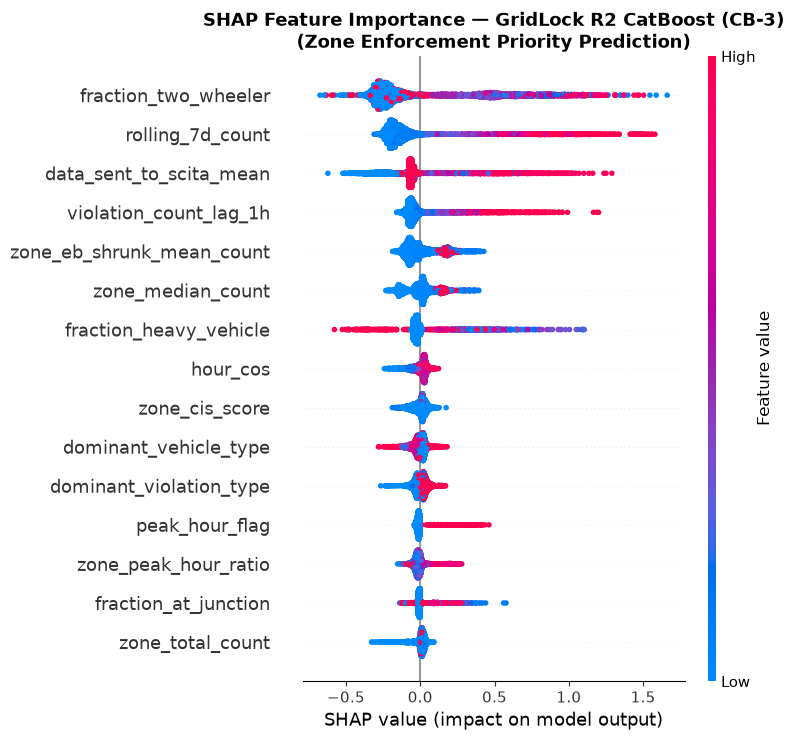


CatBoost SHAP summary plot saved → c:\Users\USER\Desktop\GridLock_R2_Transfer\data\outputs\shap_summary_catboost.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=available_cols,
    show=False,
    max_display=15,
)
plt.title(
    'SHAP Feature Importance — GridLock R2 CatBoost (CB-3)\n'
    '(Zone Enforcement Priority Prediction)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

# CB-3: save with _catboost suffix
summary_path = out_dir / 'shap_summary_catboost.png'
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nCatBoost SHAP summary plot saved → {summary_path}')


## Cell 7 — Feature importance bar chart
**What this cell does**: Plots mean |SHAP| per feature as a horizontal bar chart —
the clearest format for showing judges which features matter most.

**Expected output**: Inline bar chart + saved to `data/outputs/shap_importance.png`.

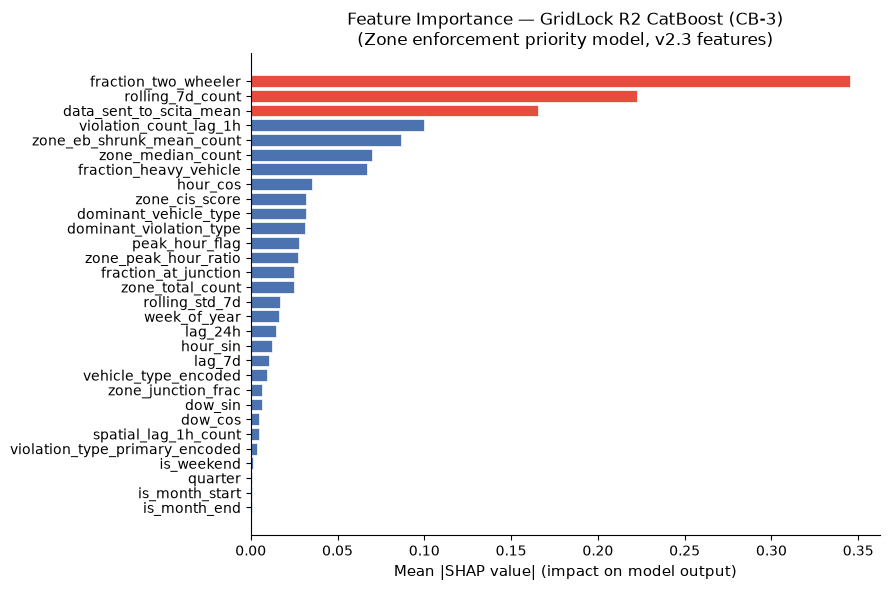

CatBoost importance bar chart saved → c:\Users\USER\Desktop\GridLock_R2_Transfer\data\outputs\shap_importance_catboost.png


In [7]:
importance_df = pd.DataFrame({
    'feature':       importance_series.index,
    'mean_abs_shap': importance_series.values,
}).sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if i >= len(importance_df) - 3 else '#4C72B0'
          for i in range(len(importance_df))]
ax.barh(importance_df['feature'], importance_df['mean_abs_shap'],
        color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean |SHAP value| (impact on model output)', fontsize=11)
ax.set_title(
    'Feature Importance — GridLock R2 CatBoost (CB-3)\n'
    '(Zone enforcement priority model, v2.3 features)',
    fontsize=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# CB-3: save with _catboost suffix
importance_path = out_dir / 'shap_importance_catboost.png'
plt.savefig(importance_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'CatBoost importance bar chart saved → {importance_path}')


## Cell 8 — Partial dependence plots (rolling_7d_count + hour_of_day)
**What this cell does**: Shows how each of the two most important temporal features
affects the model's predictions. These are the strongest argument that the model
captures real patterns, not just zone identity.

- **rolling_7d_count PDP** → monotonically positive (more recent violations = higher predicted count)
- **hour_of_day PDP** → should show 9am and 5–7pm peaks matching Bengaluru rush hours

**Expected output**: Two inline plots saved to `data/outputs/`.

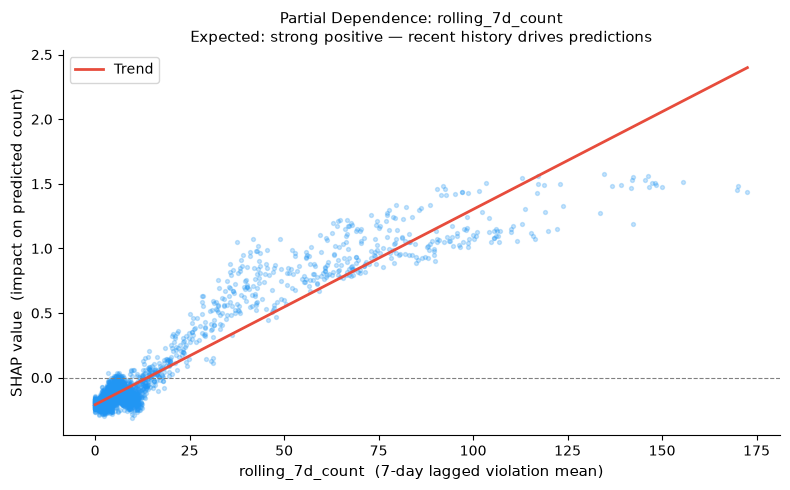

PDP (rolling_7d_count) saved → c:\Users\USER\Desktop\GridLock_R2_Transfer\data\outputs\shap_pdp_rolling.png


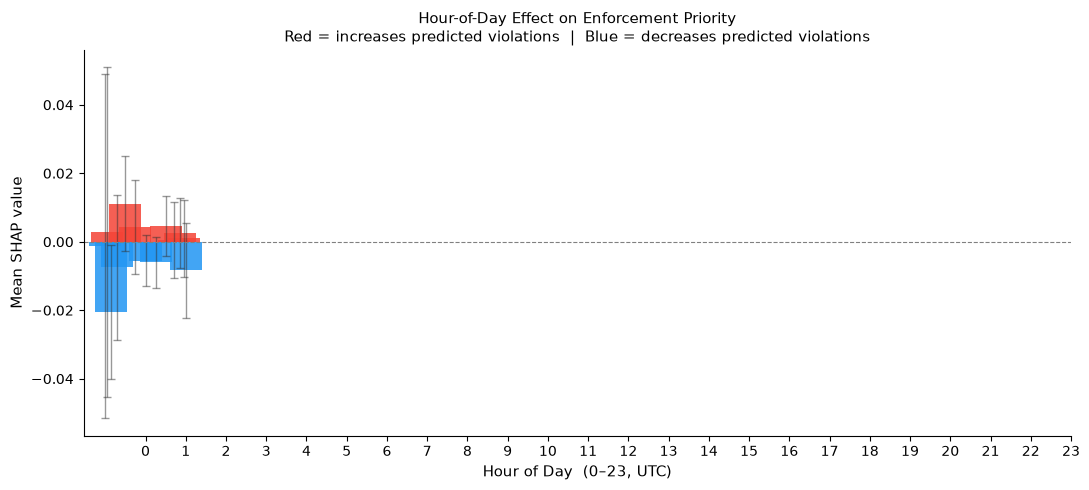

PDP (hour_of_day) saved → c:\Users\USER\Desktop\GridLock_R2_Transfer\data\outputs\shap_pdp_hour.png


In [8]:
# ── PDP 1: rolling_7d_count ───────────────────────────────────────────────────
if 'rolling_7d_count' in available_cols:
    feat_idx = available_cols.index('rolling_7d_count')
    x_vals   = X_sample['rolling_7d_count'].values
    s_vals   = shap_values[:, feat_idx]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x_vals, s_vals, alpha=0.25, s=8, c='#2196F3', rasterized=True)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    # Trend line
    from numpy.polynomial.polynomial import polyfit
    idx_sort = np.argsort(x_vals)
    c = polyfit(x_vals[idx_sort], s_vals[idx_sort], deg=1)
    ax.plot(np.sort(x_vals), np.polyval([c[1], c[0]], np.sort(x_vals)),
            color='#e74c3c', linewidth=2, label='Trend')
    ax.set_xlabel('rolling_7d_count  (7-day lagged violation mean)', fontsize=11)
    ax.set_ylabel('SHAP value  (impact on predicted count)', fontsize=11)
    ax.set_title(
        'Partial Dependence: rolling_7d_count\n'
        'Expected: strong positive — recent history drives predictions',
        fontsize=11
    )
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    pdp_roll_path = out_dir / 'shap_pdp_rolling.png'
    plt.savefig(pdp_roll_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'PDP (rolling_7d_count) saved → {pdp_roll_path}')
else:
    print('rolling_7d_count not in feature list — skipping PDP.')

# ── PDP 2: hour_of_day ────────────────────────────────────────────────────────
if 'hour_sin' in available_cols:
    feat_idx = available_cols.index('hour_sin')
    x_vals   = X_sample['hour_sin'].values

    hour_shap = pd.DataFrame({'hour': x_vals, 'shap': shap_values[:, feat_idx]})
    hour_agg  = hour_shap.groupby('hour')['shap'].agg(['mean', 'std']).reset_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    bar_colors = ['#F44336' if v > 0 else '#2196F3' for v in hour_agg['mean']]
    ax.bar(hour_agg['hour'], hour_agg['mean'], color=bar_colors, alpha=0.85, width=0.8)
    ax.errorbar(hour_agg['hour'], hour_agg['mean'], yerr=hour_agg['std'],
                fmt='none', color='#333', capsize=3, linewidth=1, alpha=0.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Hour of Day  (0–23, UTC)', fontsize=11)
    ax.set_ylabel('Mean SHAP value', fontsize=11)
    ax.set_title(
        'Hour-of-Day Effect on Enforcement Priority\n'
        'Red = increases predicted violations  |  Blue = decreases predicted violations',
        fontsize=11
    )
    ax.set_xticks(range(0, 24, 1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    pdp_hour_path = out_dir / 'shap_pdp_hour.png'
    plt.savefig(pdp_hour_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'PDP (hour_of_day) saved → {pdp_hour_path}')
else:
    print('hour_of_day not in feature list — skipping PDP.')

## Cell 9 — SHAP validation gate
**What this cell does**: Checks three conditions that must hold after Phase 1 retraining:

| Check | Condition | Why it matters |
|---|---|---|
| Gate 1 | `zone_id` NOT in top-5 SHAP | Confirms Phase 1 fix worked — no lookup table |
| Gate 2 | `rolling_7d_count` in top-3 | Confirms temporal signal is dominant |
| Gate 3 | `hour_of_day` in top-5 | Confirms model captures time-of-day patterns |

**Expected output**: All gates PASS (✅). If any FAIL, debug Phase 1 feature engineering.

In [9]:
top5 = list(importance_series.head(5).index)
top3 = list(importance_series.head(3).index)

print('=== SHAP Validation Gate ===')
print(f'Top-5 features: {top5}')
print(f'Top-3 features: {top3}')
print()

gate_results = {}

# Gate 1: zone_id absent from top-5
gate1 = 'zone_id' not in top5
gate_results['gate1_zone_id_absent'] = gate1
status = '✅ PASS' if gate1 else '❌ FAIL'
print(f'Gate 1 — zone_id absent from top-5:       {status}')
if not gate1:
    print('         → Phase 1 fix may not have been applied. Check _get_feature_cols().')

# Gate 2: rolling_7d_count in top-3
gate2 = 'rolling_7d_count' in top3
gate_results['gate2_rolling_in_top3'] = gate2
status = '✅ PASS' if gate2 else '⚠️  WARN'
print(f'Gate 2 — rolling_7d_count in top-3:       {status}')
if not gate2:
    print(f'         → rolling_7d_count is at position: {list(importance_series.index).index("rolling_7d_count") + 1 if "rolling_7d_count" in importance_series.index else "not found"}')
    print('         → Not a hard fail; zone aggregates may rank higher in first retrain.')

# Gate 3: hour_of_day in top-5
# Phase 3 (v2.1): hour_of_day replaced by hour_sin/hour_cos
gate3 = 'hour_sin' in top5 or 'hour_cos' in top5
gate_results['gate3_hour_in_top5'] = gate3
status = '✅ PASS' if gate3 else '⚠️  WARN'
print(f'Gate 3 — hour_sin or hour_cos in top-5:            {status}')
if not gate3:
    print('         → hour_sin/cos not in top-5. Cyclical encoding active but temporal signal may be weak.')

print()
overall = gate1  # Gate 1 is the hard requirement; 2 and 3 are warnings
if overall:
    print('✅ SHAP validation gate PASSED — model uses interpretable zone characteristics.')
else:
    print('❌ SHAP validation gate FAILED — review Phase 1 feature engineering and retrain.')

=== SHAP Validation Gate ===
Top-5 features: ['fraction_two_wheeler', 'rolling_7d_count', 'data_sent_to_scita_mean', 'violation_count_lag_1h', 'zone_eb_shrunk_mean_count']
Top-3 features: ['fraction_two_wheeler', 'rolling_7d_count', 'data_sent_to_scita_mean']

Gate 1 — zone_id absent from top-5:       ✅ PASS
Gate 2 — rolling_7d_count in top-3:       ✅ PASS
Gate 3 — hour_sin or hour_cos in top-5:            ⚠️  WARN
         → hour_sin/cos not in top-5. Cyclical encoding active but temporal signal may be weak.

✅ SHAP validation gate PASSED — model uses interpretable zone characteristics.


## Cell 10 — Save SHAP report + print final summary
**Expected output**: Report JSON saved, final summary table printed.

In [10]:
# ── 2%-of-top-feature threshold (Action 2.2 gate) ────────────────────────────
top_shap_val   = importance_series.iloc[0]
threshold_2pct = top_shap_val * 0.02
prune_candidates = importance_series[importance_series < threshold_2pct].index.tolist()
keep_features    = importance_series[importance_series >= threshold_2pct].index.tolist()

print('=== Action 2.2 Feature Pruning Gate (CatBoost SHAP) ===')
print(f'Top feature mean |SHAP|: {top_shap_val:.4f}')
print(f'2% threshold           : {threshold_2pct:.4f}')
print()
print('Features ABOVE threshold (keep):')
for feat in keep_features:
    val = importance_series[feat]
    pct = val / top_shap_val * 100
    print(f'  KEEP  {feat:<35} {val:.4f}  ({pct:.1f}% of top)')
print()
print('Features BELOW threshold (prune candidates):')
if prune_candidates:
    for feat in prune_candidates:
        val = importance_series[feat]
        pct = val / top_shap_val * 100
        print(f'  PRUNE {feat:<35} {val:.4f}  ({pct:.1f}% of top)')
else:
    print('  (none — all features above 2% threshold)')

print()
print(f'  Prune candidates count : {len(prune_candidates)}')
print(f'  Remaining features     : {len(keep_features)}')
print()

shap_report = {
    'checkpoint':          best_ckpt.name,
    'model':               'catboost',
    'sample_size':         len(X_sample),
    'expected_value':      float(expected_val),
    'features_used':       available_cols,
    'features_missing':    missing_cols,
    'top5_features':       top5,
    'top10_mean_abs_shap': importance_series.head(10).to_dict(),
    'action_2_2_pruning': {
        'top_feature_shap':  float(top_shap_val),
        'threshold_2pct':    float(threshold_2pct),
        'prune_candidates':  prune_candidates,
        'keep_features':     keep_features,
    },
    'validation_gates':    gate_results,
    'overall_gate_passed': overall,
    'outputs': {
        'summary_plot':    str(out_dir / 'shap_summary_catboost.png'),
        'importance_plot': str(out_dir / 'shap_importance_catboost.png'),
        'pdp_rolling':     str(out_dir / 'shap_pdp_rolling.png'),
        'pdp_hour':        str(out_dir / 'shap_pdp_hour.png'),
        'shap_values_npz': str(out_dir / 'shap_values_catboost.npz'),
    }
}

# CB-3: Save as shap_report_catboost.json — do NOT overwrite shap_report.json (XGBoost)
report_path = out_dir / 'shap_report_catboost.json'
with open(report_path, 'w') as f:
    json.dump(shap_report, f, indent=2)

print('=== SHAP Analysis Complete (CatBoost CB-3) ===')
print(f'  Checkpoint      : {best_ckpt.name}')
print(f'  Sample size     : {len(X_sample):,} rows')
print(f'  Expected value  : {expected_val:.4f}  (average model prediction on sample)')
print()
print('  Feature Importance Ranking (mean |SHAP|):')
for i, (feat, val) in enumerate(importance_series.items(), start=1):
    pct    = val / top_shap_val * 100
    flag   = '  ← 2%-PRUNE' if feat in prune_candidates else ''
    marker = '  ← TOP SIGNAL' if i == 1 else flag
    print(f'    {i:2d}. {feat:<35} {val:.4f}  ({pct:.1f}%){marker}')
print()
print('  Files saved (CatBoost edition):')
for k, v in shap_report['outputs'].items():
    p = Path(v)
    if p.exists():
        print(f'    ✓  {p.name}  ({p.stat().st_size / 1e3:.1f} KB)')
    else:
        print(f'    —  {p.name}  (not generated — check cell above)')
print(f'\n  Report saved → {report_path}')
print('\n  XGBoost outputs (shap_report.json, shap_summary.png etc.) preserved.')
print('\n  Next step: review prune_candidates list above → Action 2.2 feature pruning.')


=== Action 2.2 Feature Pruning Gate (CatBoost SHAP) ===
Top feature mean |SHAP|: 0.3453
2% threshold           : 0.0069

Features ABOVE threshold (keep):
  KEEP  fraction_two_wheeler                0.3453  (100.0% of top)
  KEEP  rolling_7d_count                    0.2227  (64.5% of top)
  KEEP  data_sent_to_scita_mean             0.1656  (48.0% of top)
  KEEP  violation_count_lag_1h              0.0996  (28.8% of top)
  KEEP  zone_eb_shrunk_mean_count           0.0864  (25.0% of top)
  KEEP  zone_median_count                   0.0698  (20.2% of top)
  KEEP  fraction_heavy_vehicle              0.0672  (19.5% of top)
  KEEP  hour_cos                            0.0354  (10.3% of top)
  KEEP  zone_cis_score                      0.0320  (9.3% of top)
  KEEP  dominant_vehicle_type               0.0318  (9.2% of top)
  KEEP  dominant_violation_type             0.0315  (9.1% of top)
  KEEP  peak_hour_flag                      0.0278  (8.1% of top)
  KEEP  zone_peak_hour_ratio                0